In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter
import matplotlib.tri as tri
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

##Local module with the functions shared across the figures below
import NMCG_utils as nu

##Local Module for figures style
import plt_conf as conf 
conf.general()

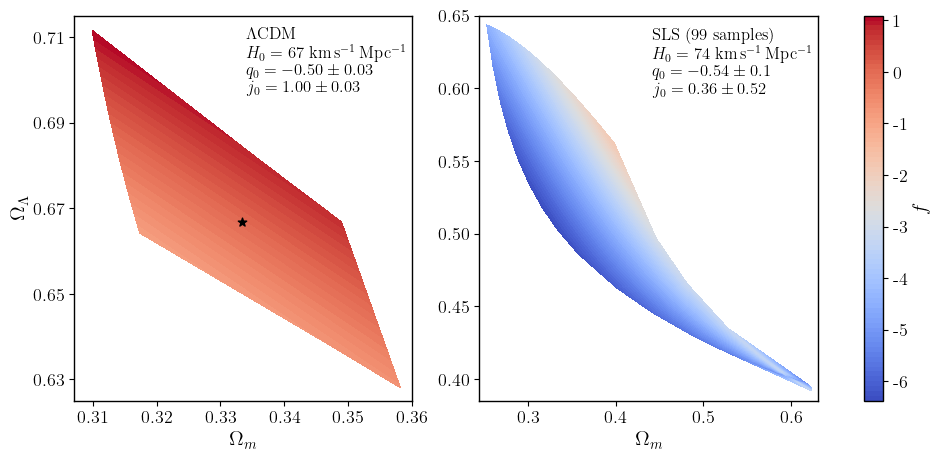

In [5]:
# =========================
# Data Load
# =========================

pointsSLS = np.loadtxt("Data/SLS_rhoNeg_Sigma_20Samples.csv", delimiter=",")
pointsCDM = np.loadtxt("Data/CDM_rhoNeg_Sigma.csv", delimiter=",")

# =========================
# Central Points
# =========================

centralCDM = [0.333333, 0.666667]

# =========================
# Rango global de f
# =========================

fmin = min(pointsSLS[:, 2].min(), pointsCDM[:, 2].min())
fmax = max(pointsSLS[:, 2].max(), pointsCDM[:, 2].max())

norm = Normalize(vmin=fmin, vmax=fmax)
levels = np.linspace(fmin, fmax, 80)

# =========================
# Figure
# =========================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# ====
# Suavizar la Figura
# ===
per=98 #Indica que tanto hay que suavizar la figura
triCDM = nu.masked_triangulation(pointsCDM[:, 0], pointsCDM[:, 1], percentile=per)
triSLS = nu.masked_triangulation(pointsSLS[:, 0], pointsSLS[:, 1], percentile=per)

# =========================
# CDM 
# =========================


contourCDM = ax1.tricontourf(
    triCDM,
    pointsCDM[:, 2],
    levels=levels,
    cmap="coolwarm",
    norm=norm
)

ax1.scatter(
    centralCDM[0],
    centralCDM[1],
    color="black",
    marker="*",
    s=40,
    zorder=10
)

ax1.set_xlabel(r"$\Omega_m$")
ax1.set_ylabel(r"$\Omega_\Lambda$")

ax1.set_xlim(0.307, 0.36)
ax1.set_ylim(0.625, 0.715)
ax1.set_yticks([0.63, 0.65,0.67,0.69, 0.71])


# =========================
# SLS 
# =========================

contourSLS = ax2.tricontourf(
    triSLS,
    pointsSLS[:, 2],
    levels=levels,
    cmap="coolwarm",
    norm=norm
)

ax2.set_xlabel(r"$\Omega_m$")
#ax2.set_ylabel(r"$\Omega_\Lambda$")

ax2.set_xlim(0.245, 0.63)
ax2.set_ylim(0.385, 0.65)

cbar = fig.colorbar(
    contourSLS,
    ax=[ax1, ax2],
    location="right"
)

cbar.set_label(r"$f$")

cbar.set_ticks([-6, -5,-4,-3, -2, -1, 0, 1])

cbar.ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.0f")
)


##Text in the graph 

ax1.text(
    0.51, 0.97,
    r"$\Lambda$CDM" "\n"
    r"$H_0 = 67\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$" "\n"
    r"$q_0=-0.50\pm0.03$" "\n"
    r"$j_0=1.00\pm0.03$",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=12
)



ax2.text(
    0.51, 0.97,
    r"SLS (99 samples)" "\n"
    r"$H_0 = 74\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$" "\n"
    r"$q_0=-0.54\pm0.1$" "\n"
    r"$j_0=0.36\pm0.52$",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=12
)

fig.savefig("../Plots/f_Area_Values.pdf", bbox_inches="tight")


(0.33, 0.9)

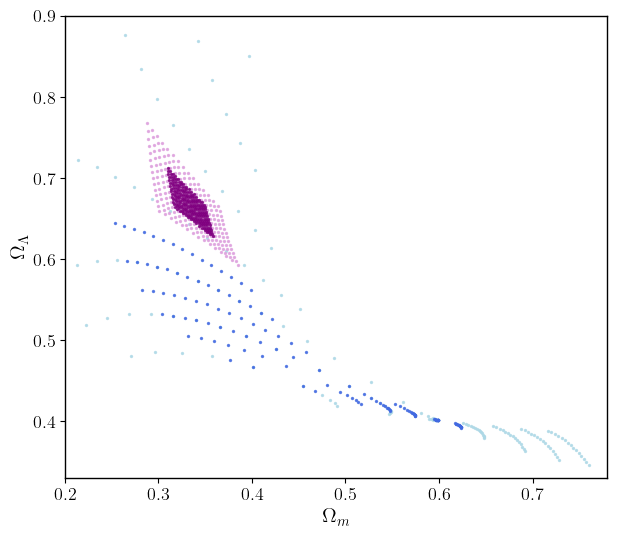

In [ ]:
pointsCDM2S = np.loadtxt("Data/CDM_rhoNeg_2S.csv", delimiter=",")
pointsCDMSigma = np.loadtxt("Data/CDM_rhoNeg_Sigma.csv", delimiter=",")

pointsSLS2S = np.loadtxt("Data/SLS_rhoNeg_2S.csv", delimiter=",")
pointsSLSSigma = np.loadtxt("Data/SLS_rhoNeg_Sigma.csv", delimiter=",")

# Punto central CDM
central = [0.333333, 0.666667]

fig, ax = plt.subplots(figsize=(7, 6))


zCDM2S = np.ones(len(pointsCDM2S))
zCDMSigma = np.ones(len(pointsCDMSigma))
zSLS2S = np.ones(len(pointsSLS2S))
zSLSSigma = np.ones(len(pointsSLSSigma))

# =========================


# =========================
# SLS — 2 Sigma
# =========================

ax.scatter(
    pointsSLS2S[:, 0],
    pointsSLS2S[:, 1],
    s=8,
    color="lightblue",
    alpha=0.8,
    marker="."
)

# =========================
# SLS — 1 Sigma
# =========================

ax.scatter(
    pointsSLSSigma[:, 0],
    pointsSLSSigma[:, 1],
    s=8,
    color="royalblue",
    alpha=0.8,
    marker="."
)

# =========================
# CDM — 2 Sigma
# =========================

ax.scatter(
    pointsCDM2S[:, 0],
    pointsCDM2S[:, 1],
    s=8,
    color="plum",
    alpha=0.8,
    marker="."
)

# =========================
# CDM — 1 Sigma
# =========================

ax.scatter(
    pointsCDMSigma[:, 0],
    pointsCDMSigma[:, 1],
    s=8,
    color="purple",
    alpha=0.8,
    marker="."
)

# =========================
# Axis
# =========================

ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")

ax.set_xlim(0.2, 0.78)
ax.set_ylim(0.33, 0.9)



In [26]:
pointsSLS2S = np.loadtxt("Data/SLS_rhoNeg_2S.csv", delimiter=",")

modulos = np.sqrt(
    pointsSLS2S[:, 0]**2 +
    pointsSLS2S[:, 1]**2
)

orden = np.argsort(modulos)

pointsSLS2S_ordenados = pointsSLS2S[orden]

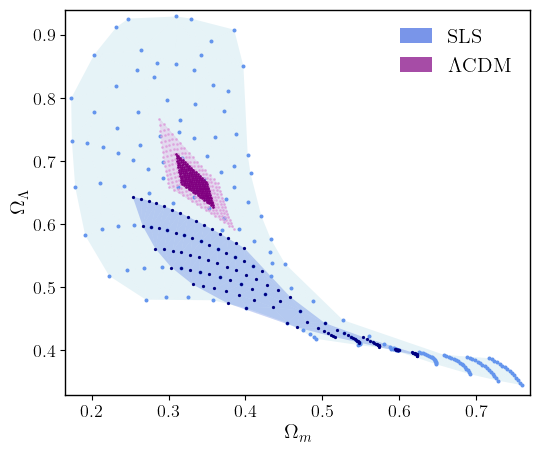

In [4]:
size_v = 3.5
alpha_area = 0.3

fig, ax = plt.subplots(figsize=(6, 5))

# =========================
# Datos
# =========================

pointsCDMSigma = np.loadtxt("Data/CDM_rhoNeg_Sigma.csv", delimiter=",")
pointsCDM2S = np.loadtxt("Data/CDM_rhoNeg_2S.csv", delimiter=",")

pointsSLS2S = np.loadtxt("Data/SLS_rhoNeg_2S_v2.csv", delimiter=",")
pointsSLSSigma = np.loadtxt("Data/SLS_rhoNeg_Sigma.csv", delimiter=",")


# =========================
# Área grande: SLS 2S
# =========================

x = pointsSLS2S[:, 0]
y = pointsSLS2S[:, 1]

triang = tri.Triangulation(x, y)

triangles = triang.triangles

p0 = np.column_stack((x[triangles[:, 0]], y[triangles[:, 0]]))
p1 = np.column_stack((x[triangles[:, 1]], y[triangles[:, 1]]))
p2 = np.column_stack((x[triangles[:, 2]], y[triangles[:, 2]]))

d01 = np.sqrt(np.sum((p0 - p1)**2, axis=1))
d12 = np.sqrt(np.sum((p1 - p2)**2, axis=1))
d20 = np.sqrt(np.sum((p2 - p0)**2, axis=1))

max_edge = 0.17

mask = (
    (d01 > max_edge) |
    (d12 > max_edge) |
    (d20 > max_edge)
)

polygons = np.stack((p0, p1, p2), axis=1)
polygons = polygons[~mask]

collection = PolyCollection(
    polygons,
    facecolor="lightblue",
    edgecolor="none",
    alpha=alpha_area
)

ax.add_collection(collection)


# =========================
# Área SLS 1Sigma
# =========================

x = pointsSLSSigma[:, 0]
y = pointsSLSSigma[:, 1]

triang = tri.Triangulation(x, y)

triangles = triang.triangles

p0 = np.column_stack((x[triangles[:, 0]], y[triangles[:, 0]]))
p1 = np.column_stack((x[triangles[:, 1]], y[triangles[:, 1]]))
p2 = np.column_stack((x[triangles[:, 2]], y[triangles[:, 2]]))

d01 = np.sqrt(np.sum((p0 - p1)**2, axis=1))
d12 = np.sqrt(np.sum((p1 - p2)**2, axis=1))
d20 = np.sqrt(np.sum((p2 - p0)**2, axis=1))

max_edge = 0.1


mask = (
    (d01 > max_edge) |
    (d12 > max_edge) |
    (d20 > max_edge)
)

polygons = np.stack((p0, p1, p2), axis=1)
polygons = polygons[~mask]

collection = PolyCollection(
    polygons,
    facecolor="royalblue",
    edgecolor="royalblue",
    linewidth=0,
    alpha=alpha_area
)

collection.set_rasterized(True)

ax.add_collection(collection)


# =========================
# Área CDM 2Sigma
# =========================

x = pointsCDM2S[:, 0]
y = pointsCDM2S[:, 1]

triang = tri.Triangulation(x, y)

triangles = triang.triangles

p0 = np.column_stack((x[triangles[:, 0]], y[triangles[:, 0]]))
p1 = np.column_stack((x[triangles[:, 1]], y[triangles[:, 1]]))
p2 = np.column_stack((x[triangles[:, 2]], y[triangles[:, 2]]))

d01 = np.sqrt(np.sum((p0 - p1)**2, axis=1))
d12 = np.sqrt(np.sum((p1 - p2)**2, axis=1))
d20 = np.sqrt(np.sum((p2 - p0)**2, axis=1))

mask = (
    (d01 > max_edge) |
    (d12 > max_edge) |
    (d20 > max_edge)
)

polygons = np.stack((p0, p1, p2), axis=1)
polygons = polygons[~mask]

collection = PolyCollection(
    polygons,
    facecolor="plum",
    edgecolor="none",
    alpha=alpha_area
)

ax.add_collection(collection)


# =========================
# Área CDM 1Sigma
# =========================

x = pointsCDMSigma[:, 0]
y = pointsCDMSigma[:, 1]

triang = tri.Triangulation(x, y)

triangles = triang.triangles

p0 = np.column_stack((x[triangles[:, 0]], y[triangles[:, 0]]))
p1 = np.column_stack((x[triangles[:, 1]], y[triangles[:, 1]]))
p2 = np.column_stack((x[triangles[:, 2]], y[triangles[:, 2]]))

d01 = np.sqrt(np.sum((p0 - p1)**2, axis=1))
d12 = np.sqrt(np.sum((p1 - p2)**2, axis=1))
d20 = np.sqrt(np.sum((p2 - p0)**2, axis=1))

max_edge = 0.25

mask = (
    (d01 > max_edge) |
    (d12 > max_edge) |
    (d20 > max_edge)
)

polygons = np.stack((p0, p1, p2), axis=1)
polygons = polygons[~mask]

collection = PolyCollection(
    polygons,
    facecolor="purple",
    edgecolor="none",
    alpha=alpha_area
)

ax.add_collection(collection)

# =========================
# Puntos SLS 2S
#=========================

ax.scatter(
    pointsSLS2S[:, 0],
    pointsSLS2S[:, 1],
    color="cornflowerblue",
    s=size_v
)

# =========================
# Puntos CDM 2Sigma
# =========================

ax.scatter(
    pointsCDM2S[:, 0],
    pointsCDM2S[:, 1],
    s=size_v,
    color="plum",
    alpha=0.8,
    marker="."
)


# =========================
# Puntos CDM 1Sigma
# =========================

ax.scatter(
    pointsCDMSigma[:, 0],
    pointsCDMSigma[:, 1],
    color="purple",
    marker=".",
    s=size_v
)


# # =========================
# # Puntos SLS 1Sigma
# # =========================

ax.scatter(
    pointsSLSSigma[:, 0],
    pointsSLSSigma[:, 1],
    color="navy",
    marker=".",
    s=7
)


# =========================
# Límites
# =========================

ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\Omega_\Lambda$")

legend_elements = [
    Patch(facecolor="royalblue", alpha=0.7, label=r"SLS"),
    Patch(facecolor="purple", alpha=0.7, label=r"$\Lambda$CDM")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False
)


ax.set_xlim(0.165, 0.77)
ax.set_ylim(0.33, 0.94)

fig.savefig("../Plots/Trust_Regions.pdf", bbox_inches="tight")
